# Trabajo Práctico N.° 2 — Análisis de Series Temporales

## 08 — Deep Learning: redes LSTM

**Objetivo de este notebook:** cubrir el punto 2 de la consigna del TP2 (`docs/Consigna/TP_Final.pdf`) para la categoría "Redes Neuronales": entrenar una red LSTM univariada por serie (ozono, temperatura, radiación) y pronosticar sobre una ventana razonable (punto 3), comparando contra los enfoques estadísticos y de Machine Learning ya evaluados en `05_sarima.ipynb`, `06_var.ipynb` y `07_pronosticos.ipynb`.

**Por qué LSTM:** una red recurrente de este tipo puede aprender dependencias no lineales de largo y corto plazo sin necesidad de especificar manualmente un orden autorregresivo, a diferencia de SARIMA/VAR. Se sigue el patrón de ventana deslizante + escalado visto en los ejemplos de Clase 6 (`PRACTICA_AST_Clase_6_2A_LSTM.ipynb`), adaptado a nuestras series horarias.

**Dataset:** se usa `serie_california_tratada.csv` (salida de `07b_tratamiento_datos.ipynb`: atípicos aislados corregidos, huecos del índice temporal ya interpolados) en vez de `serie_california.csv`. `01`-`07` no se recalculan con este dataset — sólo `08` en adelante.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from dl_utils import crear_dataset_supervisado, escalar_serie

tf.random.set_seed(123)

datos = pd.read_csv(
    PROJECT_ROOT / "data/processed/serie_california_tratada.csv",
    index_col="datetime_utc",
    parse_dates=True,
)
print(f"Filas: {len(datos):,} | Rango: {datos.index.min()} -> {datos.index.max()}")
print(f"GPUs detectadas por TensorFlow: {tf.config.list_physical_devices('GPU')} (se entrena en CPU)")

Filas: 242,402 | Rango: 1998-01-01 08:00:00 -> 2025-08-27 09:00:00


GPUs detectadas por TensorFlow: [] (se entrena en CPU)


## 1. Ventana de entrenamiento y configuración

Entrenar una LSTM sobre las ~239.000 horas completas de cada serie es innecesariamente costoso (se midió: el tiempo por época escala con la cantidad de secuencias de entrenamiento) y no aporta más señal que una ventana reciente representativa, igual que se hizo con SARIMA y VAR. Se usa **1 año** de historia por serie para entrenar, reservando las últimas 168 horas (7 días) como holdout — el mismo horizonte de evaluación que SARIMA, VAR y los modelos de `07_pronosticos.ipynb`, para que las métricas sean comparables.

In [2]:
VENTANA_DIAS = 365
HORAS_TEST = 24 * 7
INPUT_LENGTH = 24  # un dia de historia para predecir la hora siguiente
EPOCHS = 50
BATCH_SIZE = 256

print(f"Ventana de entrenamiento: {VENTANA_DIAS} días | Holdout: {HORAS_TEST} horas | Input LSTM: {INPUT_LENGTH} horas")

Ventana de entrenamiento: 365 días | Holdout: 168 horas | Input LSTM: 24 horas


## 2. Entrenamiento y evaluación por serie

Para cada serie: se recorta la ventana reciente, se separa el holdout final, se escala con `MinMaxScaler` ajustado sólo en el tramo de entrenamiento (para no filtrar información del futuro), se arma el dataset supervisado con ventana deslizante, y se entrena una LSTM simple (una capa recurrente + una capa densa de salida).

In [3]:
resultados_lstm = {}
historiales = {}

for col in datos.columns:
    print(f"\n{'='*60}\n{col}\n{'='*60}")

    serie_completa = datos[col].reset_index(drop=True)
    ventana = serie_completa.iloc[-(VENTANA_DIAS * 24):].values
    train_val, test = ventana[:-HORAS_TEST], ventana[-HORAS_TEST:]

    scaler, train_val_s, test_s = escalar_serie(train_val, test)

    X, Y = crear_dataset_supervisado(train_val_s, INPUT_LENGTH, output_length=1)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    modelo = Sequential([
        Input(shape=(INPUT_LENGTH, 1)),
        LSTM(64),
        Dense(1, activation="linear"),
    ])
    modelo.compile(optimizer="adam", loss="mse")

    t0 = time.time()
    historia = modelo.fit(
        X, Y, epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_split=0.1, verbose=0,
    )
    dt = time.time() - t0
    print(f"Entrenamiento: {EPOCHS} épocas -> {dt:.1f}s")

    # Pronostico recursivo sobre las HORAS_TEST horas de holdout: se arranca
    # con las ultimas INPUT_LENGTH horas de train_val (escaladas) y cada
    # prediccion se reincorpora como input del siguiente paso.
    entrada = train_val_s[-INPUT_LENGTH:].tolist()
    predicciones_s = []
    for _ in range(HORAS_TEST):
        x = np.array(entrada[-INPUT_LENGTH:]).reshape((1, INPUT_LENGTH, 1))
        pred = modelo.predict(x, verbose=0)[0, 0]
        predicciones_s.append(pred)
        entrada.append(pred)

    predicciones = scaler.inverse_transform(np.array(predicciones_s).reshape(-1, 1)).flatten()

    mae = mean_absolute_error(test, predicciones)
    rmse = mean_squared_error(test, predicciones) ** 0.5
    resultados_lstm[col] = {"MAE": mae, "RMSE": rmse, "epochs": EPOCHS, "input_length": INPUT_LENGTH}
    historiales[col] = historia.history["loss"]
    print(f"[LSTM - {col}] MAE={mae:.5f}  RMSE={rmse:.5f}")

    resultados_lstm[col]["_test_real"] = test.tolist()
    resultados_lstm[col]["_test_pred"] = predicciones.tolist()


ozono_ppm


Entrenamiento: 50 épocas -> 37.4s


[LSTM - ozono_ppm] MAE=0.01172  RMSE=0.01599

temperatura_c


Entrenamiento: 50 épocas -> 33.3s


[LSTM - temperatura_c] MAE=3.46761  RMSE=4.23301

radiacion_ghi_wm2


Entrenamiento: 50 épocas -> 35.7s


[LSTM - radiacion_ghi_wm2] MAE=62.89061  RMSE=90.98487


## 3. Curvas de entrenamiento y pronóstico

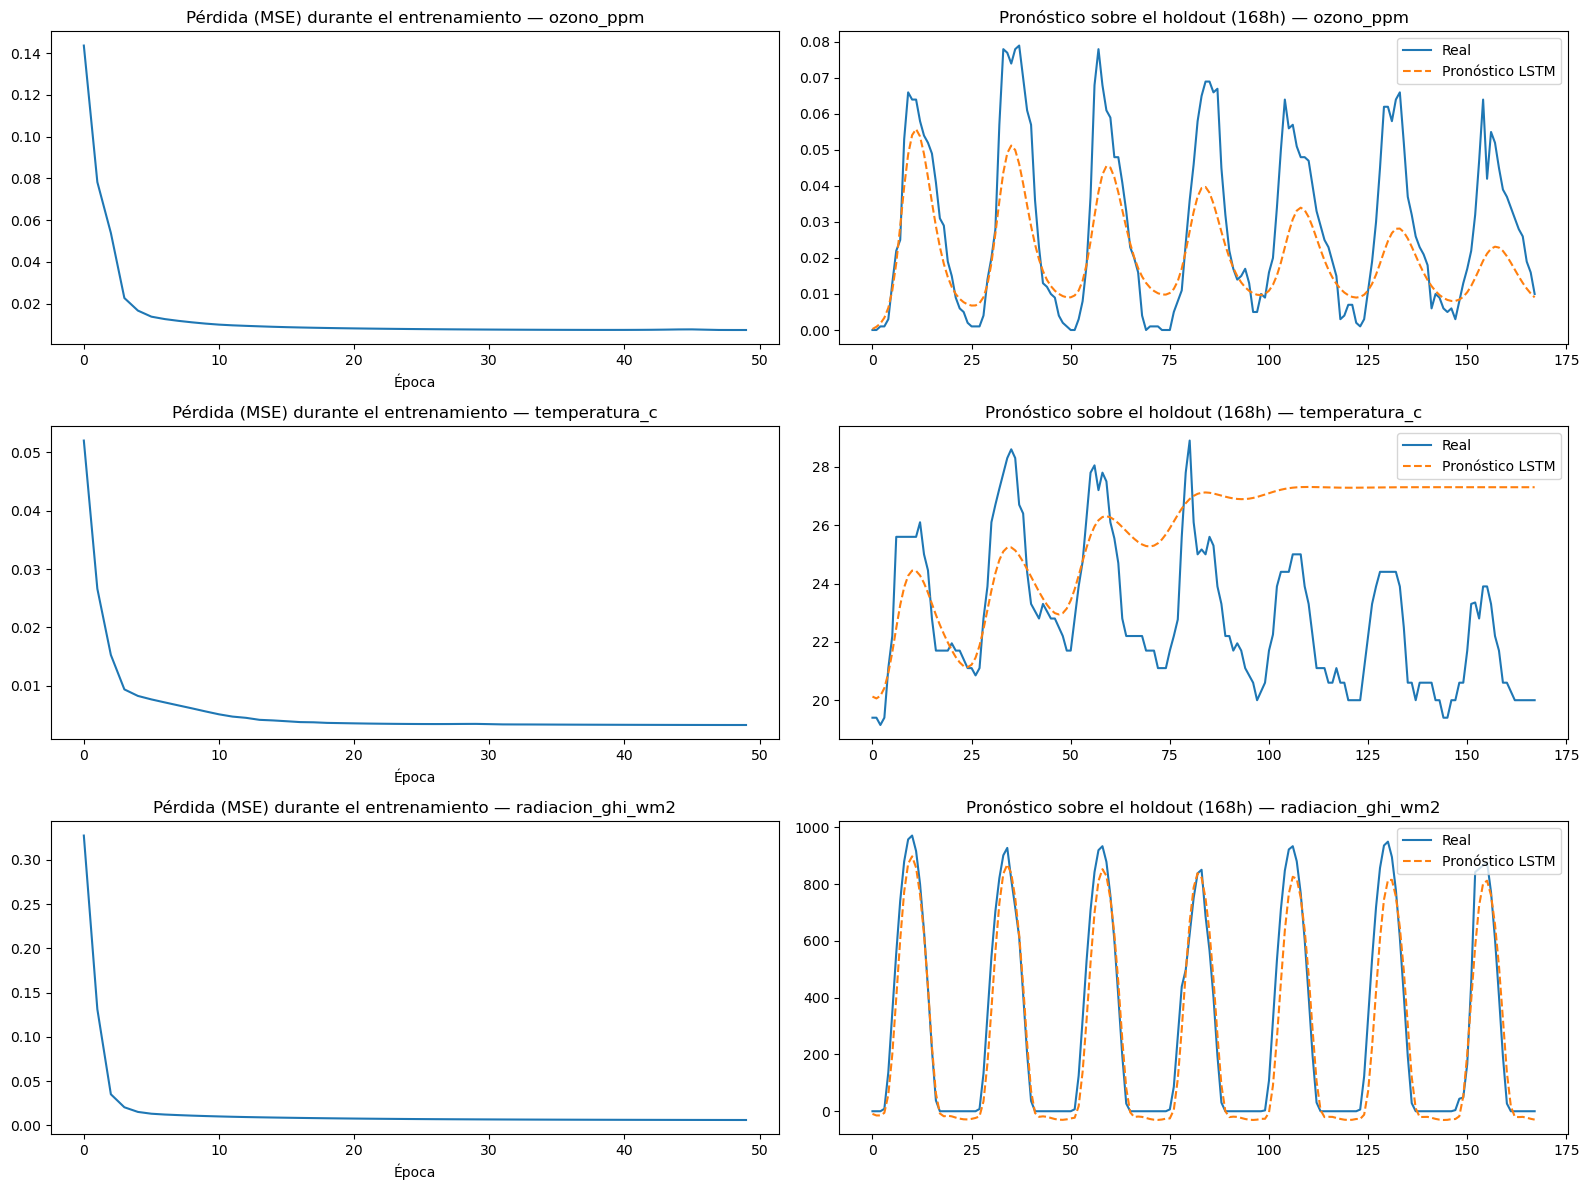

In [4]:
fig, axes = plt.subplots(len(datos.columns), 2, figsize=(16, 12))

for fila, col in enumerate(datos.columns):
    axes[fila, 0].plot(historiales[col])
    axes[fila, 0].set_title(f"Pérdida (MSE) durante el entrenamiento — {col}")
    axes[fila, 0].set_xlabel("Época")

    real = resultados_lstm[col]["_test_real"]
    pred = resultados_lstm[col]["_test_pred"]
    axes[fila, 1].plot(real, label="Real")
    axes[fila, 1].plot(pred, label="Pronóstico LSTM", linestyle="--")
    axes[fila, 1].set_title(f"Pronóstico sobre el holdout (168h) — {col}")
    axes[fila, 1].legend()

plt.tight_layout()
plt.show()

## 4. Guardado de resultados

Se guardan las métricas (sin las series de detalle, ya usadas para graficar) para que `11_comparacion_final.ipynb` pueda leerlas junto con SARIMA, VAR, los ensambles de `07_pronosticos.ipynb` y el resto de los modelos de este TP.

In [5]:
resultados_a_guardar = {
    col: {k: v for k, v in resultados_lstm[col].items() if not k.startswith("_")}
    for col in datos.columns
}

destino = PROJECT_ROOT / "data/processed/resultados_lstm.json"
destino.write_text(json.dumps(resultados_a_guardar, indent=2), encoding="utf-8")

print(json.dumps(resultados_a_guardar, indent=2))
print(f"\nGuardado en {destino}")
print("\nProyecto listo para continuar con 09_prophet_neuralprophet.ipynb")

{
  "ozono_ppm": {
    "MAE": 0.01172007396658938,
    "RMSE": 0.01598618262214586,
    "epochs": 50,
    "input_length": 24
  },
  "temperatura_c": {
    "MAE": 3.467611782134525,
    "RMSE": 4.233010253893252,
    "epochs": 50,
    "input_length": 24
  },
  "radiacion_ghi_wm2": {
    "MAE": 62.890606885155044,
    "RMSE": 90.98487473553885,
    "epochs": 50,
    "input_length": 24
  }
}

Guardado en C:\Series_AMBA\data\processed\resultados_lstm.json

Proyecto listo para continuar con 09_prophet_neuralprophet.ipynb
